# Plot Training Logs

**Plot the training logs of a model you have trained.** 

This notebook plots the Learning Rate (Eta), the Exploration Rate (Epsilon), the Reward by Episode and the Loss by Episode as a function of the episode.

Command to Pip Install pandas included.

In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
#Add path to model you have trained
PATH = "../models/0610_2304_CarDQNAgent"
logs = pd.read_csv(os.path.join(PATH,"log.csv"))
logs.tail()

,Time,Step,Episode,Loss,Reward,Eta,Epsilon,Action
25995,427.37,25996,2896,0.000008,0.0,0.002,0.4494,3
25996,427.37,25997,2896,0.000140,0.0,0.002,0.4494,1
25997,427.38,25998,2896,0.000027,0.0,0.002,0.4494,2
25998,427.39,25999,2896,0.000018,0.0,0.002,0.4494,0
25999,427.40,26000,2896,0.000594,0.0,0.002,0.4493,3


In [144]:
logs_by_episode = logs.groupby('Episode').sum('Reward').reset_index()
logs_by_episode.head()

,Episode,Time,Step,Loss,Reward,Eta,Epsilon,Action
0,0,2.76,1,0.0,-1.0,0.002,1.0000,1
1,1,2.78,2,0.0,-1.0,0.002,1.0000,1
2,2,2.78,3,0.0,-1.0,0.002,0.9999,1
3,3,20.07,49,0.0,-1.0,0.014,6.9986,9
4,4,2.91,11,0.0,-1.0,0.002,0.9997,1


In [145]:
def plot_logs(logs, title):

    logs_by_episode = logs.groupby('Episode').sum('Reward').reset_index()


    fig, axs = plt.subplots(2,2)


    fig.suptitle(title, fontsize=14)


    #Subplot #1
    axs[0,0].plot(logs["Episode"], logs['Eta']);
    axs[0,0].set_ylabel('Eta')
    axs[0,0].set_xlabel('Episode')
    axs[0,0].set_yscale('log')

    #Subplot #2:
    axs[0,1].plot(logs["Episode"], logs['Epsilon']);
    axs[0,1].set_ylabel('Epsilon')
    axs[0,1].set_xlabel('Episode')
    #axs[0,1].set_yscale('log')

    #Subplot #3:
    axs[1,0].plot(logs_by_episode["Episode"], logs_by_episode['Reward']);
    axs[1,0].set_ylabel('Reward by Episode')
    axs[1,0].set_xlabel('Episode')
    #axs[1,0].set_yscale('log')


    #Subplot #4:
    axs[1,1].plot(logs_by_episode["Episode"], logs_by_episode['Loss']);
    axs[1,1].set_ylabel('Loss by Episode')
    axs[1,1].set_xlabel('Episode')
    #axs[1,1].set_yscale('log')

    fig.tight_layout()

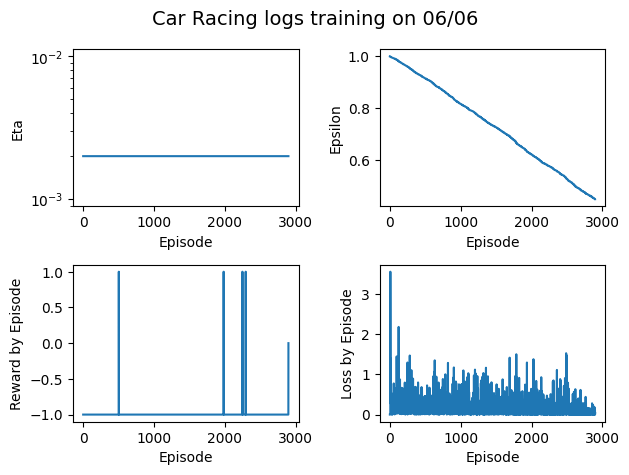

In [146]:
plot_logs(logs, 'Car Racing logs training on 06/06')

#### Rolling avg. reward

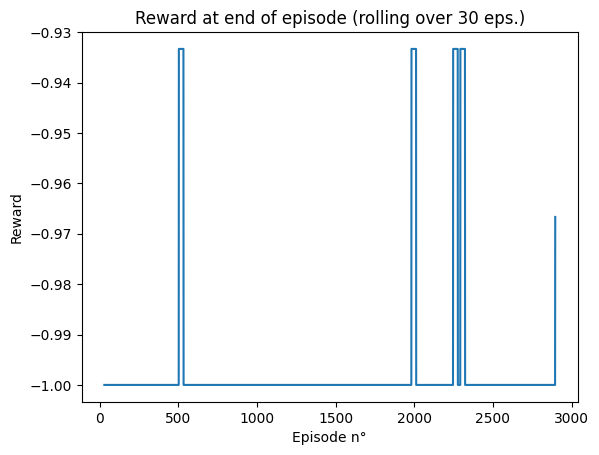

In [147]:
rolling_rewards = logs.groupby('Episode').sum()['Reward'].rolling(30).mean()
ax = rolling_rewards.plot()
ax.set_title('Reward at end of episode (rolling over 30 eps.)')
ax.set_xlabel('Episode n°')
ax.set_ylabel('Reward');

#### Episode length (in steps)

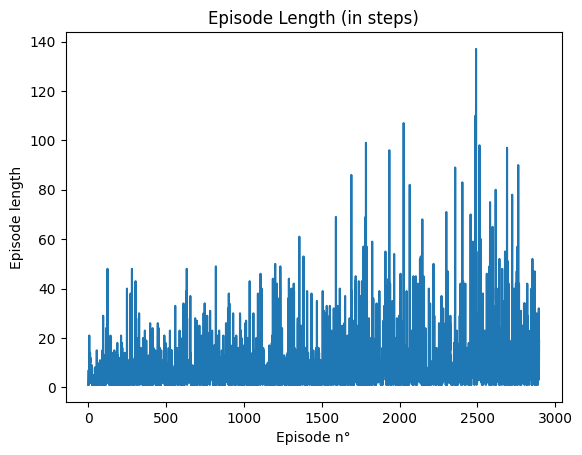

In [148]:
logs_by_episode = logs.groupby('Episode').count()
ax = logs_by_episode['Time'].plot()
ax.set_title('Episode Length (in steps)')
ax.set_xlabel('Episode n°')
ax.set_ylabel('Episode length');

### Action pdf as a function of episode

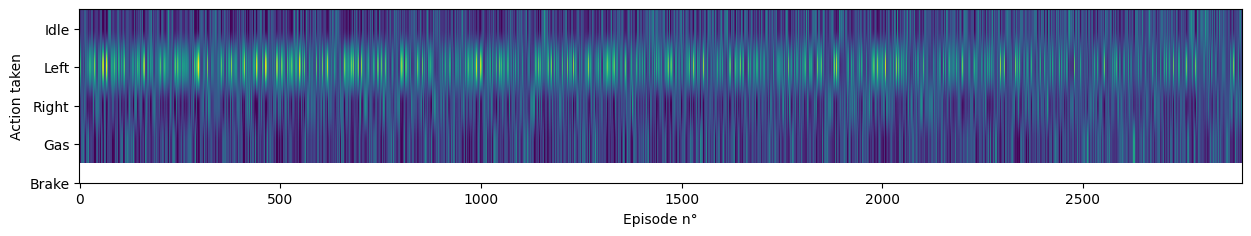

In [149]:
action_count_per_ep = logs[['Episode', 'Action']].groupby('Episode').value_counts(normalize=True).unstack(level=-1)
action_count_per_ep[action_count_per_ep.isna()] = 0
neps = action_count_per_ep.index.max()
fig, ax = plt.subplots()
ax.imshow(np.array(action_count_per_ep).T, aspect=np.maximum(1,neps//30))
fig.set_size_inches(w=15, h=4)


# # Frozen Lake
# ax.set_yticks([0,1,2,3])
# ax.set_yticklabels(['Left', 'Down', 'Right', 'Up'])

# Car Race
ax.set_yticks([0,1,2,3,4])
ax.set_yticklabels(['Idle', 'Left', 'Right', 'Gas', 'Brake'])

ax.set_xlabel('Episode n°')
ax.set_ylabel('Action taken');

#### Graphing the reward time series for each episode 
(see if at least the model is progressing)

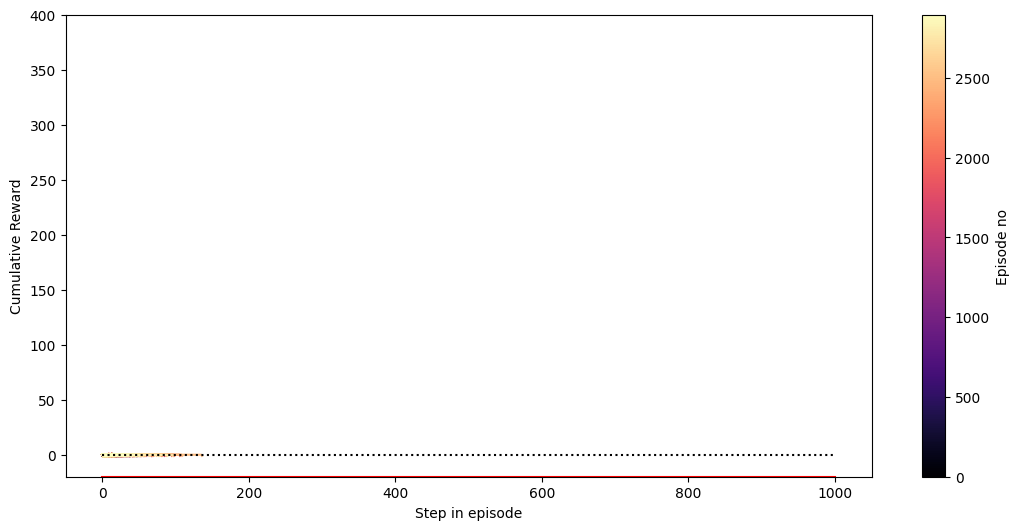

In [150]:
import matplotlib as mpl
import matplotlib.cm as cm


fig, ax = plt.subplots()
neps = logs['Episode'].max()
cmap = cm.magma

for episode in range(neps):
    rewards_ep = logs[logs['Episode'] == episode]['Reward'].cumsum().to_numpy()
    ax.plot(rewards_ep, color=cmap(episode/neps))

ax.plot([0, 1000], [-20, -20], 'r')
ax.plot([0, 1000], [0, 0], 'k:')

ax.set_xlabel('Step in episode')
ax.set_ylabel('Cumulative Reward')
ax.set_ylim([-20,400])
fig.set_size_inches(w=13, h=6)

norm = mpl.colors.Normalize(vmin=0, vmax=neps)
fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
             ax=ax, label='Episode no')